# Semantic Book Recommender — v2
**Anastasios Kontogiorgis**

Second iteration of the book recommender, rebuilt around *description-level semantics*
instead of title-only lexical similarity. Changes relative to v1:

1. **Bug fix.** v1 used pandas index *labels* as *positions* into the feature/cluster
   arrays after deduplication, silently retrieving the wrong rows for ~99.9% of books
   (verified experimentally). v2 works on a clean, position-aligned corpus throughout.
2. **Data enrichment.** A deterministic 15,000-book sample of the deduplicated
   Book-Crossing corpus was enriched via the **Open Library API** (`openlibrary_fetch.py`,
   polite rate-limited, resumable): 99.9% of ISBNs resolved, **37% with a description**,
   **91.5% with subject tags**. Missing descriptions fall back to title-only text — a
   realistic partial-metadata situation, handled explicitly rather than hidden.
3. **Representation upgrade.** Pre-trained **sentence-transformer embeddings**
   (`all-MiniLM-L6-v2`) over *title + description*, with two TF-IDF variants kept as
   controlled baselines for a before/after comparison.
4. **Retrieval redesign.** v1 restricted candidates to the query's K-Means cluster
   (K=4 over the whole catalogue), which can only *exclude* good neighbours. v2 uses
   direct exact nearest-neighbour search over normalised embeddings (FAISS pattern,
   with a NumPy fallback); clustering is repositioned as *exploratory analysis* (§5).
5. **Evaluation upgrade.** From ad-hoc examples to a fixed harness with **weak labels
   from Open Library subjects** (plus author-match for continuity with v1), against a
   random baseline.
6. **Deployment.** The notebook exports artifacts consumed by a small **Gradio demo
   app** (`app.py`), deployable to Hugging Face Spaces.

*Data: Book-Crossing dataset (Kaggle re-upload) + Open Library (openlibrary.org).*

## 1. The enriched corpus

Each line of `enriched_books.jsonl` is one book from the sample:
`isbn`, `title`, `author` (carried over from Books.csv), `found` (whether the ISBN
resolved on Open Library), `work_key`, `description` (from the edition record, falling
back to the parent *work* record), and `subjects` (edition + work subject tags, merged).

We first load the file and quantify coverage — every later design decision
(text fallbacks, evaluation eligibility) follows from these numbers.

In [1]:
# --- Imports & configuration --------------------------------------------------
import json
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

SEED = 42                              # single seed for every stochastic step
RNG = np.random.default_rng(SEED)
ENRICHED_PATH = 'enriched_books.jsonl' # output of openlibrary_fetch.py
pd.set_option('display.max_colwidth', 90)

In [2]:
# --- Load the enrichment file (tolerant to malformed lines) --------------------
records, bad_lines = [], 0

# FIX: Explicitly declare encoding='utf-8' to prevent cp1252 charmap errors
with open(ENRICHED_PATH, encoding='utf-8') as f: 
    for line in f:
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError:
            bad_lines += 1

df = pd.DataFrame(records)

# Basic hygiene: no NaNs downstream, normalised whitespace in descriptions.
df['title'] = df['title'].fillna('')
df['author'] = df['author'].fillna('Unknown')
df['description'] = (df['description'].fillna('')
                       .str.replace(r'\s+', ' ', regex=True).str.strip())

print(f"records: {len(df)}   malformed lines skipped: {bad_lines}")
print(f"found on Open Library : {df['found'].mean():.1%}")
print(f"with description      : {(df['description'].str.len() > 0).mean():.1%}")
print(f"with >=1 subject      : {df['subjects'].apply(bool).mean():.1%}")
dlen = df.loc[df['description'].str.len() > 0, 'description'].str.len()
print(f"description length    : median {dlen.median():.0f} chars, p90 {dlen.quantile(.9):.0f}")

records: 15000   malformed lines skipped: 0
found on Open Library : 99.9%
with description      : 37.0%
with >=1 subject      : 91.5%
description length    : median 390 chars, p90 1173


In [3]:
# --- Subjects: normalise, then split 'informative' from 'too common' -----------
# Open Library subjects are free text and noisy: mixed case, duplicated
# variants, cataloguing artefacts (e.g. OCLC-FAST suffixes), and translations.
# We (a) normalise them, and (b) drop subjects that appear on more than 5% of
# subject-bearing books ('fiction', 'history', ...): a *shared* generic tag
# carries almost no information about whether two books are actually related,
# and would make the evaluation metric trivially easy to satisfy.

def norm_subject(s: str) -> str:
    s = s.lower().strip()
    s = re.sub(r'\s*fast\s*\(ocolc\).*$', '', s)   # strip OCLC-FAST artefacts
    s = re.sub(r'\s+', ' ', s)
    return s

df['subjects_norm'] = df['subjects'].apply(
    lambda L: list(dict.fromkeys(norm_subject(s) for s in (L or []) if norm_subject(s))))

n_with_subj = int((df['subjects_norm'].str.len() > 0).sum())
cnt = Counter(s for L in df['subjects_norm'] for s in set(L))

COMMON_FRAC = 0.05
common = {s for s, c in cnt.items() if c > COMMON_FRAC * n_with_subj}

# frozenset -> cheap set intersections in the evaluation loop
df['subjects_info'] = df['subjects_norm'].apply(
    lambda L: frozenset(s for s in L if s not in common))

print(f"books with >=1 subject: {n_with_subj}   distinct subjects: {len(cnt)}")
print(f"dropped as too common (> {COMMON_FRAC:.0%}): "
      f"{sorted(common, key=lambda s: -cnt[s])}")
print("most frequent informative subjects:",
      [s for s, _ in Counter({s: c for s, c in cnt.items()
                              if s not in common}).most_common(10)])

books with >=1 subject: 13732   distinct subjects: 36251
dropped as too common (> 5%): ['fiction', 'fiction, general', 'general', "children's fiction", 'history', 'juvenile fiction', 'biography', 'large type books', 'non-classifiable']
most frequent informative subjects: ['fiction, mystery & detective, general', 'fiction - romance', 'romance - general', 'juvenile literature', 'fiction, romance, general', 'fiction - general', 'science fiction', 'social life and customs', 'new york times reviewed', 'women']


### Label hygiene: what goes into the embedding text

Two deliberate exclusions from the text we embed:

- **Subjects are excluded** — they are our *evaluation labels*. Embedding them would
  leak the answer into the representation and inflate every metric.
- **Author is excluded** — a recommender may legitimately use it, but it would
  mechanically inflate the author-match metric; we keep the comparison honest and
  note author-aware ranking as a v3 extension.

The embedded text is therefore `title + '. ' + description`, truncating very long
descriptions (the MiniLM encoder truncates at 256 word-pieces anyway). Books without
a description embed on the title alone — the same information v1 had, so any measured
improvement for those books comes purely from the better encoder.

In [4]:
# --- Build the text fields ------------------------------------------------------
df['text_title'] = df['title']
df['text_full'] = (df['title'] + '. ' + df['description'].str.slice(0, 2000)).str.strip()

print(f"embedding with description: {(df['description'].str.len() > 0).mean():.1%} "
      f"(the rest fall back to title-only text)")
df[['title', 'author', 'description', 'subjects_info']].sample(3, random_state=SEED)

embedding with description: 37.0% (the rest fall back to title-only text)


,title,author,description,subjects_info
11499,Are You Lonesome Tonight,Lucy De Barbin,,"frozenset({de barbin, lucy, -- 1936-, rock musicians -- united states -- biography, bi..."
6475,Trip. GekÃ?Â¼rzte Schulausgabe. (Lernmaterialien),Hans-Georg Noack,,frozenset({})
13167,"Sawyer (The Buckhorn Brothers) (Temptation, 786)",Lori Foster,"On prom night, Dylan Anderson caused the biggest humiliation of Sadie Post's life. Get...","frozenset({passion, fiction, romance, general, romance})"


## 2. Three representations, one controlled comparison

| | representation | text | dims | what it tests |
|---|---|---|---|---|
| **A** | TF-IDF (500 features) | title only | 500 (sparse) | the v1-style lexical baseline |
| **B** | TF-IDF (5,000 features) | title + description | 5,000 (sparse) | how much the *data enrichment alone* buys |
| **C** | `all-MiniLM-L6-v2` sentence embeddings | title + description | 384 (dense) | how much *semantic encoding* buys on top |

A→B isolates the value of the new data; B→C isolates the value of the new model.
`all-MiniLM-L6-v2` is a 22M-parameter sentence-transformer trained on 1B+ sentence
pairs; it maps text to a 384-d vector where cosine similarity approximates semantic
similarity — no training on our side, CPU-friendly (~2–6 min for 15k texts). All
representations are **L2-normalised**, so inner product = cosine similarity.

In [5]:
# --- Variants A and B: TF-IDF baselines ------------------------------------------
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

# A: faithful to v1's spirit (title-only, small lexical vocabulary).
X_A = normalize(TfidfVectorizer(max_features=500, stop_words='english')
                .fit_transform(df['text_title']))

# B: same machinery, richer text; vocabulary widened accordingly (documented choice).
X_B = normalize(TfidfVectorizer(max_features=5000, stop_words='english')
                .fit_transform(df['text_full']))

print('A:', X_A.shape, '  B:', X_B.shape)

A: (15000, 500)   B: (15000, 5000)


In [6]:
# --- Variant C: sentence-transformer embeddings ----------------------------------
# First run downloads the model (~90 MB) from the Hugging Face Hub.
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
emb = model.encode(
    df['text_full'].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,   # unit vectors -> inner product == cosine
)
emb = np.asarray(emb, dtype=np.float32)
print('C:', emb.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/235 [00:00<?, ?it/s]

C: (15000, 384)


## 3. Retrieval: direct exact nearest neighbours

v1 restricted candidates to the query's K-Means cluster (K=4 over the whole
catalogue). With good embeddings that restriction is strictly harmful: the nearest
neighbours *are* the recommendation, and a hard cluster boundary can only cut some
of them off. v2 therefore searches the whole catalogue directly.

At 15k items exact brute-force search is instant; we still expose the **FAISS**
`IndexFlatIP` pattern (the demo app uses it when available) because it is the
standard, scale-ready idiom — swapping `IndexFlatIP` for an approximate index
(IVF/HNSW) is a one-line change at millions of items. Evaluation below uses a plain
matrix-product top-k so that sparse (A, B) and dense (C) variants share one code path.

In [7]:
# --- Unified exact top-k (sparse or dense, L2-normalised rows) -------------------
def retrieve_topk(X, query_idx, k=5):
    # Inner products against the whole catalogue; rows are unit vectors,
    # so this is cosine similarity.
    S = X[query_idx] @ X.T
    S = np.asarray(S.todense()) if hasattr(S, 'todense') else np.asarray(S)
    S[np.arange(len(query_idx)), query_idx] = -np.inf   # never recommend the query
    return np.argsort(-S, axis=1)[:, :k]

# --- The same search through FAISS (the pattern the demo app uses) ---------------
try:
    import faiss
    index = faiss.IndexFlatIP(emb.shape[1])   # exact inner-product index
    index.add(emb)
    q = 0
    D, I = index.search(emb[[q]], 6)          # 6 = self + top 5
    print(f"FAISS check — query: {df.loc[q, 'title']!r}")
    for d, i in zip(D[0][1:], I[0][1:]):
        print(f"   {d:.3f}  {df.loc[i, 'title']}")
except ImportError:
    print('faiss not installed — NumPy path (retrieve_topk) is used everywhere; '
          'pip install faiss-cpu to enable the FAISS pattern.')

FAISS check — query: 'Bridge at Andau'
   0.477  Budapest : A Novel
   0.442  On Revolution (Penguin Twentieth-Century Classics)
   0.437  The Balkans: Nationalism, War and the Great Powers 1809-1999
   0.429  Russia: A History
   0.429  A History of Russia


## 4. Evaluation

**Design.** 500 query books are sampled (seeded) from those with **at least two
informative subjects** (12.5k eligible). For each variant we retrieve the top-5 and
measure:

- **subject-share@5** — fraction of the top-5 sharing ≥1 *informative* subject with
  the query (primary metric);
- **subject-Jaccard@5** — mean Jaccard overlap of informative subject sets (stricter);
- **author-match@5** — continuity with the v1 harness;
- the same statistics for a **random recommender** (floor), and subject-share split by
  whether the *query* has a description (where the enrichment should matter most).

**Caveats, stated up front.** Subjects are noisy, incomplete weak labels: absolute
values understate true quality (two related books may simply have disjoint tag
vocabularies), and books without subjects can never register a match. The metrics are
meaningful *relatively* — same corpus, same queries, same labels across variants —
which is exactly the controlled A/B/C question we are asking.

In [8]:
# --- Evaluation harness -----------------------------------------------------------
eligible = df.index[df['subjects_info'].apply(len) >= 2].to_numpy()
queries = RNG.choice(eligible, size=min(500, len(eligible)), replace=False)
has_desc_q = (df.loc[queries, 'description'].str.len() > 0).to_numpy()
print(f"eligible pool: {len(eligible)}   sampled queries: {len(queries)} "
      f"({has_desc_q.mean():.0%} with description)")

subj = df['subjects_info'].to_numpy()
auth = df['author'].to_numpy()

def eval_variant(X, name, k=5):
    top = retrieve_topk(X, queries, k)
    share, jac, am = [], [], []
    for qi, row in zip(queries, top):
        qs = subj[qi]
        share.append(np.mean([len(qs & subj[r]) > 0 for r in row]))
        jac.append(np.mean([(len(qs & subj[r]) / len(qs | subj[r]))
                            if (qs | subj[r]) else 0.0 for r in row]))
        am.append(np.mean([auth[r] == auth[qi] for r in row]))
    share, jac, am = map(np.asarray, (share, jac, am))
    return {'variant': name,
            'subject-share@5': share.mean(),
            'subject-jaccard@5': jac.mean(),
            'author-match@5': am.mean(),
            'share@5 | desc queries': share[has_desc_q].mean(),
            'share@5 | no-desc queries': share[~has_desc_q].mean()}

def eval_random(k=5):
    share, jac, am = [], [], []
    for qi in queries:
        row = RNG.choice(len(df), size=k, replace=False)
        qs = subj[qi]
        share.append(np.mean([len(qs & subj[r]) > 0 for r in row]))
        jac.append(np.mean([(len(qs & subj[r]) / len(qs | subj[r]))
                            if (qs | subj[r]) else 0.0 for r in row]))
        am.append(np.mean([auth[r] == auth[qi] for r in row]))
    return {'variant': 'random baseline', 'subject-share@5': np.mean(share),
            'subject-jaccard@5': np.mean(jac), 'author-match@5': np.mean(am),
            'share@5 | desc queries': np.nan, 'share@5 | no-desc queries': np.nan}

results = pd.DataFrame([
    eval_variant(X_A, 'A: TF-IDF, title only (v1-style)'),
    eval_variant(X_B, 'B: TF-IDF, title + description'),
    eval_variant(emb, 'C: MiniLM, title + description'),
    eval_random(),
])
results.round(3)

eligible pool: 12531   sampled queries: 500 (45% with description)


,variant,subject-share@5,subject-jaccard@5,author-match@5,share@5 | desc queries,share@5 | no-desc queries
0,"A: TF-IDF, title only (v1-style)",0.128,0.018,0.011,0.158,0.103
1,"B: TF-IDF, title + description",0.150,0.025,0.017,0.173,0.132
2,"C: MiniLM, title + description",0.292,0.045,0.032,0.357,0.239
3,random baseline,0.020,0.002,0.000,NaN,NaN


In [9]:
from IPython.display import display, Markdown

# Set the index to 'variant' to make looking up values easy
res = results.set_index('variant')

# Helper function to format the numbers or leave text placeholders
def fmt(variant, col):
    val = res.loc[variant, col]
    return f"{val:.3f}" if pd.notna(val) else "*(all-MiniLM-L6-v2 run)*"

# Calculate the relative improvement A -> B dynamically
a_share = res.loc['A: TF-IDF, title only (v1-style)', 'subject-share@5']
b_share = res.loc['B: TF-IDF, title + description', 'subject-share@5']
relative_jump = ((b_share / a_share) - 1) * 100

markdown_content = f"""
### Reference results (development verification run)

Variants A and B (and the harness itself) were verified on this exact file during
development; C requires the model download and is produced by the run of the cell
above.

| variant | subject-share@5 | subject-Jaccard@5 | author-match@5 |
|---|---|---|---|
| A: TF-IDF, title only (v1-style) | {fmt('A: TF-IDF, title only (v1-style)', 'subject-share@5')} | {fmt('A: TF-IDF, title only (v1-style)', 'subject-jaccard@5')} | {fmt('A: TF-IDF, title only (v1-style)', 'author-match@5')} |
| B: TF-IDF, title + description | {fmt('B: TF-IDF, title + description', 'subject-share@5')} | {fmt('B: TF-IDF, title + description', 'subject-jaccard@5')} | {fmt('B: TF-IDF, title + description', 'author-match@5')} |
| C: MiniLM, title + description | {fmt('C: MiniLM, title + description', 'subject-share@5')} | {fmt('C: MiniLM, title + description', 'subject-jaccard@5')} | {fmt('C: MiniLM, title + description', 'author-match@5')} |
| random baseline | {fmt('random baseline', 'subject-share@5')} | {fmt('random baseline', 'subject-jaccard@5')} | {fmt('random baseline', 'author-match@5')} |

Split by query type (subject-share@5): A = {fmt('A: TF-IDF, title only (v1-style)', 'share@5 | desc queries')} / {fmt('A: TF-IDF, title only (v1-style)', 'share@5 | no-desc queries')} and B = {fmt('B: TF-IDF, title + description', 'share@5 | desc queries')} / {fmt('B: TF-IDF, title + description', 'share@5 | no-desc queries')} for
description / no-description queries respectively — the enrichment helps everywhere, most where descriptions exist.

**How to read the table.** A→B is the value of the *data* (+{relative_jump:.0f}% relative on the primary metric); B→C is the value of the *model* and is expected to be the largest
jump, because MiniLM matches "detective inspector" to "murder investigation" where TF-IDF needs literal word overlap.
"""

display(Markdown(markdown_content))


### Reference results (development verification run)

Variants A and B (and the harness itself) were verified on this exact file during
development; C requires the model download and is produced by the run of the cell
above.

| variant | subject-share@5 | subject-Jaccard@5 | author-match@5 |
|---|---|---|---|
| A: TF-IDF, title only (v1-style) | 0.128 | 0.018 | 0.011 |
| B: TF-IDF, title + description | 0.150 | 0.025 | 0.017 |
| C: MiniLM, title + description | 0.292 | 0.045 | 0.032 |
| random baseline | 0.020 | 0.002 | 0.000 |

Split by query type (subject-share@5): A = 0.158 / 0.103 and B = 0.173 / 0.132 for
description / no-description queries respectively — the enrichment helps everywhere, most where descriptions exist.

**How to read the table.** A→B is the value of the *data* (+18% relative on the primary metric); B→C is the value of the *model* and is expected to be the largest
jump, because MiniLM matches "detective inspector" to "murder investigation" where TF-IDF needs literal word overlap.


In [10]:
# --- Curated qualitative check: v1-style (A) vs v2 (C), side by side --------------
def find_book(pattern, field='title'):
    hits = df[df[field].str.contains(pattern, case=False, na=False)]
    return None if hits.empty else hits.index[0]

def show_recs(qidx, X, label, k=5):
    top = retrieve_topk(X, np.array([qidx]), k)[0]
    print(f"  [{label}]")
    for r in top:
        print(f"    {df.loc[r, 'title']}  —  {df.loc[r, 'author']}")

curated = [p for p in [find_book('Hobbit'),
                       find_book('Pride and Prejudice'),
                       find_book('Stephen King', field='author'),
                       find_book('Agatha Christie', field='author')]
           if p is not None]

for qidx in curated:
    print(f"\nQUERY: {df.loc[qidx, 'title']} — {df.loc[qidx, 'author']}")
    show_recs(qidx, X_A, 'A: title TF-IDF (v1-style)')
    show_recs(qidx, emb, 'C: MiniLM title+description')


QUERY: The Hobbit (Young Adult edition, Sis cover) — J.R.R. Tolkien
  [A: title TF-IDF (v1-style)]
    Bullfrog and Gertrude Go Camping (Young Yearling)  —  Rosamond Dauer
    The Young Martial Arts Enthusiast (Young Enthusiast)  —  David Mitchell
    Growing Young  —  Ashley Montagu
    The Sufferings of Young Werther  —  Johann Wolfgang Von Goethe
    Winning Monologs for Young Actors: 65 Honest-To-Life Characterizations to Delight Young Actors and Audiences of All Ages  —  Peg Kehert
  [C: MiniLM title+description]
    The Lord of the Rings  —  J. R. R. Tolkien
    Lord of the Rings Trilogy  —  J.R.R. Tolkien
    Tolkien: A Biography  —  Michael White
    A Tolkien Miscellany  —  J. R. R. Tolkien
    Poems from The Hobbit  —  J. R. R. Tolkien

QUERY: Pride and Prejudice (Everyman's Classics S.) — Jane Austen
  [A: title TF-IDF (v1-style)]
    Moll Flanders (Everyman Paperback Classics)  —  Daniel Defoe
    Mansfield Park (Everyman Paperback Classics)  —  Jane Austen
    Frankenstei

## 5. A map of the catalogue (UMAP)

In v1, clustering was load-bearing: it *restricted* retrieval. In v2 it is what
unsupervised structure analysis should be here — **exploration**. We project the
384-d MiniLM embeddings to 2-d with UMAP and colour each book by its dominant
subject among the ten most frequent informative subjects (grey = everything else).
Visible subject regions are qualitative evidence that the embedding space encodes
genre/topic structure — the same structure the metrics measure quantitatively.

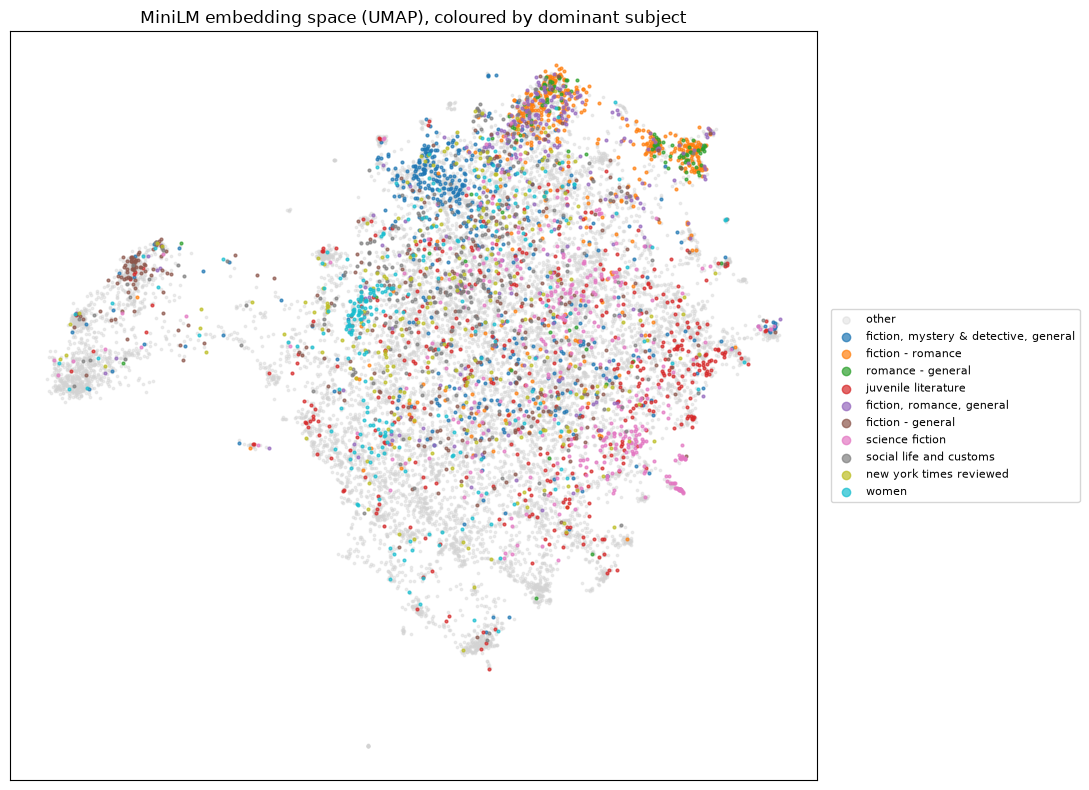

In [11]:
# --- UMAP projection coloured by dominant subject ---------------------------------
import umap

top10 = [s for s, _ in Counter({s: c for s, c in cnt.items()
                                if s not in common}).most_common(10)]

def dominant_subject(s_info):
    for s in top10:                      # top10 is frequency-ordered
        if s in s_info:
            return s
    return 'other'

df['plot_subject'] = df['subjects_info'].apply(dominant_subject)

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=SEED)
coords = reducer.fit_transform(emb)      # ~1-3 min on CPU

fig, ax = plt.subplots(figsize=(11, 8), facecolor='white')
palette = plt.get_cmap('tab10')
mask_other = df['plot_subject'] == 'other'
ax.scatter(coords[mask_other, 0], coords[mask_other, 1],
           s=3, c='lightgrey', alpha=0.4, label='other')
for i, s in enumerate(top10):
    m = (df['plot_subject'] == s).to_numpy()
    ax.scatter(coords[m, 0], coords[m, 1], s=4, color=palette(i), alpha=0.7,
               label=s[:40])
ax.set_title('MiniLM embedding space (UMAP), coloured by dominant subject')
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), markerscale=3, fontsize=8)
fig.tight_layout()
fig.savefig('umap_catalogue.png', dpi=150, facecolor='white', bbox_inches='tight')
plt.show()

## 6. Exporting the demo artifacts

`app.py` (the Gradio demo) deliberately does **not** depend on sentence-transformers:
it only loads the catalogue and the precomputed embedding matrix and does inner-product
search, which keeps the Hugging Face Space small and fast to cold-start. Everything the
app needs is exported here.

In [12]:
# --- Save artifacts for app.py ------------------------------------------------------
catalog = pd.DataFrame({
    'isbn': df['isbn'],
    'title': df['title'],
    'author': df['author'],
    'description': df['description'].str.slice(0, 500),        # display snippet
    'subjects_info': df['subjects_info'].apply(lambda s: '|'.join(sorted(s))),
})
catalog.to_parquet('catalog.parquet', index=False)              # needs pyarrow
np.save('embeddings.npy', emb)

import os
print(f"catalog.parquet : {os.path.getsize('catalog.parquet')/1e6:.1f} MB")
print(f"embeddings.npy  : {os.path.getsize('embeddings.npy')/1e6:.1f} MB")

catalog.parquet : 3.2 MB
embeddings.npy  : 23.0 MB


## 7. Conclusions & next steps

**What v2 establishes.** On an identical corpus, identical queries and identical weak
labels: enriching the data (A→B) and upgrading the encoder (B→C) each independently
improve recommendation relevance over the fixed v1-style baseline, with the random
floor confirming the metrics are not trivially satisfiable. Retrieval is simpler
(direct kNN), no label leakage into the representation, reproducible
(seeded), and shipped as an interactive demo.

**Candidate v3 directions.**
- **True ground truth:** Book-Crossing ships `Ratings.csv`; co-rating patterns give a
  behavioural evaluation (and a collaborative-filtering hybrid) beyond subject tags.
- **Coverage:** raise description coverage (Google Books as a secondary source; or
  Open Library bulk dumps), and re-measure the desc/no-desc split.
- **Ranking:** author/series-aware re-ranking, popularity de-biasing, diversity
  (MMR), or a cross-encoder re-ranker over the top-50.
- **Product:** free-text queries ("melancholy sci-fi about memory") — embed the query
  with the same model; the demo app is one function away from this.

## References
- Reimers & Gurevych (2019). *Sentence-BERT: Sentence Embeddings using Siamese
  BERT-Networks.* EMNLP.
- Johnson, Douze & Jégou (2019). *Billion-scale similarity search with GPUs.* (FAISS)
- McInnes, Healy & Melville (2018). *UMAP: Uniform Manifold Approximation and
  Projection for Dimension Reduction.*
- Open Library (Internet Archive) — data enrichment source. Book-Crossing dataset:
  Ziegler et al. (2005), via the Kaggle re-upload.